# **YOLO 파인튜닝**

# 1.환경준비

## (1) 라이브러리 설치

In [1]:
!pip install ultralytics roboflow -q

## (2) 라이브러리 불러오기

In [2]:
from ultralytics import settings, YOLO
from roboflow import Roboflow
import matplotlib.pyplot as plt
import cv2
import os
from IPython.display import Video

* 폴더 내 이미지 개수 확인

In [3]:
def image_count(path) :
    image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]  # YOLO에서 지원하는 이미지 확장자

    # valid 폴더에서 이미지 파일 개수 확인
    image_count = len([f for f in os.listdir(path) if f.lower().endswith(tuple(image_extensions))])

    return image_count

## (3) YOLO 설정

* 파일 경로 설정

In [4]:
# 현재 세팅을 확인해 봅시다.
settings

{'settings_version': '0.0.6',
 'datasets_dir': '/content/',
 'weights_dir': 'weights',
 'runs_dir': 'runs',
 'uuid': '569f3ba64b326db489132663f79cd37279811de477381b83ac131e6cdd129cbb',
 'sync': True,
 'api_key': '',
 'openai_api_key': '',
 'clearml': True,
 'comet': True,
 'dvc': True,
 'hub': True,
 'mlflow': True,
 'neptune': True,
 'raytune': True,
 'tensorboard': False,
 'wandb': False,
 'vscode_msg': True,
 'openvino_msg': True}

In [5]:
# 콜랩 파일 탭에 보이는 경로('/content/')로 변경해 봅시다.
settings['datasets_dir'] = '/content/'
settings.update()
settings

{'settings_version': '0.0.6',
 'datasets_dir': '/content/',
 'weights_dir': 'weights',
 'runs_dir': 'runs',
 'uuid': '569f3ba64b326db489132663f79cd37279811de477381b83ac131e6cdd129cbb',
 'sync': True,
 'api_key': '',
 'openai_api_key': '',
 'clearml': True,
 'comet': True,
 'dvc': True,
 'hub': True,
 'mlflow': True,
 'neptune': True,
 'raytune': True,
 'tensorboard': False,
 'wandb': False,
 'vscode_msg': True,
 'openvino_msg': True}

# 2.모델링

## (1) 데이터셋 다운로드

![](https://i.imgur.com/xIudTbe.png)

* 아래 링크를 눌러 데이터셋 다운로드 코드를 받아 옵시다.

    - **[링크](https://universe.roboflow.com/roboflow-58fyf/rock-paper-scissors-sxsw)**

In [6]:
rf = Roboflow(api_key="oFyNbRkwU6FgJ7qvcFn5")
project = rf.workspace("roboflow-58fyf").project("rock-paper-scissors-sxsw")
version = project.version(14)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...


* 이미지 개수 확인

In [7]:
# train 이미지
cnt = image_count('/content/rock-paper-scissors-14/train/images')
print('* train 이미지 수 :', cnt)

# valid 이미지
cnt = image_count('/content/rock-paper-scissors-14/valid/images')
print('* valid 이미지 수 :', cnt)

# test 이미지
cnt = image_count('/content/rock-paper-scissors-14/test/images')
print('* test 이미지 수 :', cnt)

* train 이미지 수 : 6455
* valid 이미지 수 : 576
* test 이미지 수 : 304


## (2) 모델

### 1) 모델 다운로드

- 모델의 구조와 해당 구조에 맞게 사전 학습된 가중치를 불러온다.
- Parameters
    * model : 모델 구조 또는 모델 구조 + 가중치 설정. task와 맞는 모델을 선택해야 한다.
    * task : detect, segment, classify, pose 중 택일

In [8]:
model = YOLO(model='yolo11n.pt', task='detect')

### 2) 모델 살펴보기

**다음 내용은 참조하세요.**
* Backbone : CNN 기반 특징 추출기 (0~9)
    * 입력 이미지를 받아서 엣지, 텍스처, 형태 같은 저수준~중간 수준의 특징을 뽑음.
    * 보통 Conv, C3 블록, SPPF 같은 모듈이 포함됨.
    * YOLO 에서 0~9번 레이어 (Conv → C3k2 → … → SPPF) 가 여기에 해당
* Neck : 다중 스케일 특징 결합기 (10~22)
    * 여러 단계의 feature map을 서로 결합해서 더 풍부한 표현을 만듦.
    * FPN이나 PAN 구조를 써서 작은 물체부터 큰 물체까지 다 잡을 수 있도록 함.
    * Upsample, Concat, C3k2 같은 블록들이 여기에 해당 (10~22번).
* Head : 최종 예측기 (23)
    * 실제로 bounding box 좌표와 클래스 확률을 출력하는 부분.
    * YOLO에서는 Detect 모듈 (23번)이 여기에 해당.

* 요약 정보 (레이어 수, 파라미터 수 등)

In [9]:
model.info()

YOLO11n summary: 181 layers, 2,624,080 parameters, 0 gradients, 6.6 GFLOPs


(181, 2624080, 0, 6.614336)

* 모델 블록 단위 확인하기
    * 블록 안에 하위 레이어들이 포함된다.

In [10]:
# 레이어 구조 확인
for i, m in enumerate(model.model.model):
    print(f"{i:3d} : {m.__class__.__name__}")

  0 : Conv
  1 : Conv
  2 : C3k2
  3 : Conv
  4 : C3k2
  5 : Conv
  6 : C3k2
  7 : Conv
  8 : C3k2
  9 : SPPF
 10 : C2PSA
 11 : Upsample
 12 : Concat
 13 : C3k2
 14 : Upsample
 15 : Concat
 16 : C3k2
 17 : Conv
 18 : Concat
 19 : C3k2
 20 : Conv
 21 : Concat
 22 : C3k2
 23 : Detect


* 전체 네트워크 아키텍처 출력

In [11]:
print(model.model)

DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C3k2(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
   

## (3) 파인튜닝

* 모델 학습
    * 파라미터 설명 : [Parameters](https://docs.ultralytics.com/modes/train/#train-settings)

In [12]:
results_train = model.train(model='/content/yolov11n.pt',
                            data='/content/rock-paper-scissors-14/data.yaml',
                            epochs=3,
                            seed=20,
                            optimizer = 'Adam',
                            pretrained=True,
                            lr0 = 0.0001 )

Ultralytics 8.3.217 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/rock-paper-scissors-14/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/yolov11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overlap_mask=True, patience=100, perspectiv

In [13]:
valid_folder = "/content/rock-paper-scissors-14/valid/images"  # valid 폴더 경로 지정
image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]  # YOLO에서 지원하는 이미지 확장자

# valid 폴더에서 이미지 파일 개수 확인
image_count = len([f for f in os.listdir(valid_folder) if f.lower().endswith(tuple(image_extensions))])

print(f"Valid 폴더의 이미지 개수: {image_count}")

Valid 폴더의 이미지 개수: 576


## (4) 평가

In [14]:
# 테스트 이미지로 모델 평가하기
results = model.val(data='/content/rock-paper-scissors-14/data.yaml', split="test")

Ultralytics 8.3.217 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1083.3±396.6 MB/s, size: 24.1 KB)
val: Scanning /content/rock-paper-scissors-14/test/labels.cache... 304 images, 118 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 304/304 664.8Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 4.1it/s 4.6s
                   all        304        204      0.792       0.79      0.867      0.634
                 Paper         72         72      0.712       0.75      0.806      0.537
                  Rock         59         65      0.804      0.882      0.908       0.69
              Scissors         66         67      0.861      0.737      0.886      0.676
Speed: 2.3ms preprocess, 4.5ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to /content/runs/detec

## (5) 예측해보기

In [15]:
image_path = 'https://cdn.crowdpic.net/detail-thumb/thumb_d_7CBEBAEF3FFE8DD37E4912332908E40F.png'


Found https://cdn.crowdpic.net/detail-thumb/thumb_d_7CBEBAEF3FFE8DD37E4912332908E40F.png locally at thumb_d_7CBEBAEF3FFE8DD37E4912332908E40F.png
image 1/1 /content/thumb_d_7CBEBAEF3FFE8DD37E4912332908E40F.png: 448x640 1 Paper, 1 Rock, 1 Scissors, 48.1ms
Speed: 2.3ms preprocess, 48.1ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict4


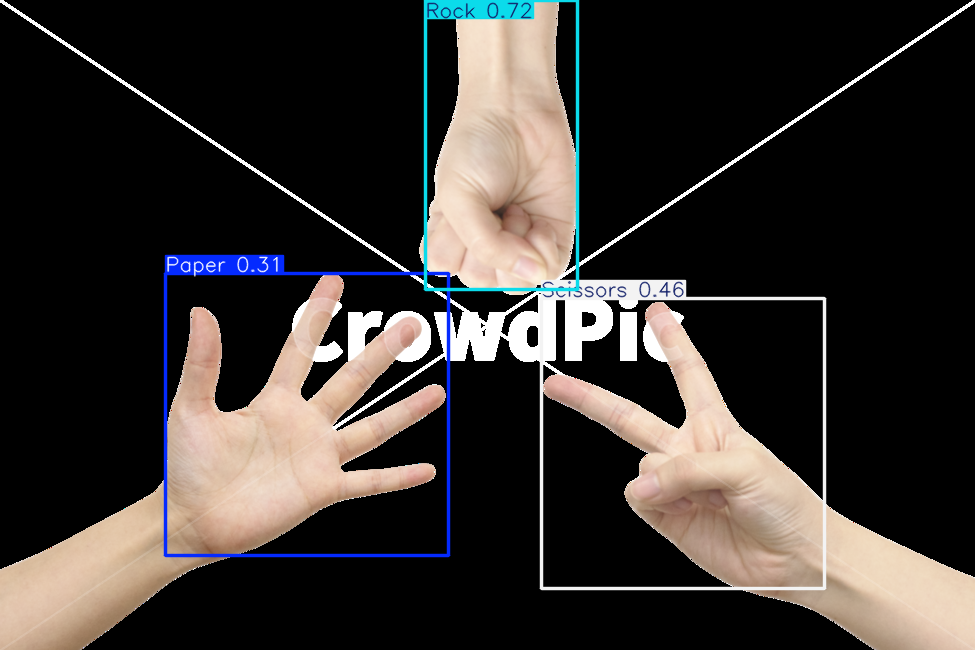

In [16]:
result = model.predict(source=image_path, save=True)
result[0].show()  # 탐지된 객체 출력

## (6)[추가] YOLO모델 구조에 처음부터 학습시키기
* 권장하지 않습니다.

* 모델 구조 선택하기

In [17]:
model_scratch = YOLO(model='yolo11n.pt', task='detect')

* 모델 학습하기

In [18]:
results_train = model_scratch.train(model='/content/yolo11n.pt',
                                    data='/content/rock-paper-scissors-14/data.yaml',
                                    epochs=1,
                                    patience=5,
                                    seed=20,
                                    optimizer = 'Adam',
                                    pretrained=False,
                                    )

Ultralytics 8.3.217 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/rock-paper-scissors-14/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train5, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overlap_mask=True, patience=5, perspective=0.0

* 예측해보기

In [19]:
image_path = 'https://cdn.crowdpic.net/detail-thumb/thumb_d_7CBEBAEF3FFE8DD37E4912332908E40F.png'

In [20]:
results_pred = model_scratch.predict(source=image_path, stream=False, save=True)


Found https://cdn.crowdpic.net/detail-thumb/thumb_d_7CBEBAEF3FFE8DD37E4912332908E40F.png locally at thumb_d_7CBEBAEF3FFE8DD37E4912332908E40F.png
image 1/1 /content/thumb_d_7CBEBAEF3FFE8DD37E4912332908E40F.png: 448x640 4 Scissorss, 8.6ms
Speed: 2.1ms preprocess, 8.6ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict5


In [21]:
results_pred

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Paper', 1: 'Rock', 2: 'Scissors'}
 obb: None
 orig_img: array([[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        ...,
 
        [[153, 179, 210],
         [152, 178, 209],
         [156, 180, 211],
         ...,
         [190, 209, 233],
         [184, 206, 231],
         [184, 205, 232]],
 
        [[151, 177, 208],
         [158, 182, 212],
         [165, 187, 214],
       

# 3.실습

## (1) 데이터셋 다운로드

* [roboflow universe](https://universe.roboflow.com/)에서 원하는 데이터를 하나 선정해서 직접 다운로드 받고 파인튜닝 해 봅시다.
    * 만약 딱히 떠오르는게 없다면 ▶ [football player](https://universe.roboflow.com/ilyes-talbi-ptwsp/futbol-players/dataset/9/download/yolov11)


* 데이터셋 다운로드 코드

In [22]:
from roboflow import Roboflow
rf = Roboflow(api_key="oFyNbRkwU6FgJ7qvcFn5")
project = rf.workspace("ilyes-talbi-ptwsp").project("futbol-players")
version = project.version(9)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...


## (2) 모델 다운로드

- 모델의 구조와 해당 구조에 맞게 사전 학습된 가중치를 불러온다.
- Parameters
    * model : 모델 구조 또는 모델 구조 + 가중치 설정. task와 맞는 모델을 선택해야 한다.
    * task : detect, segment, classify, pose 중 택일

In [23]:
model = YOLO(model='yolo11n.pt', task='detect')

## (3) 파인튜닝1
* 앞의 모델 코드를 그대로 이용하되, 에포크(epochs)와 학습율(lr0)만 조정한다.

### 1) 학습

* 모델 학습

In [24]:
results_train = model.train(model='/content/yolov11n.pt',
                            data='/content/futbol-players-9/data.yaml',
                            epochs=3,
                            seed=20,
                            optimizer = 'Adam',
                            pretrained=True,
                            lr0 = 0.0001
                            )

Ultralytics 8.3.217 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/futbol-players-9/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/yolov11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train6, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overlap_mask=True, patience=100, perspective=0.0,

In [25]:
valid_folder = "/content/futbol-players-9/valid/images"  # valid 폴더 경로 지정
image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]  # YOLO에서 지원하는 이미지 확장자

# valid 폴더에서 이미지 파일 개수 확인
image_count = len([f for f in os.listdir(valid_folder) if f.lower().endswith(tuple(image_extensions))])

print(f"Valid 폴더의 이미지 개수: {image_count}")

Valid 폴더의 이미지 개수: 33


### 2) 평가

In [26]:
# 테스트 이미지로 모델 평가하기
results = model.val(data='/content/futbol-players-9/data.yaml', split="test")

Ultralytics 8.3.217 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 888.8±298.3 MB/s, size: 20.4 KB)
val: Scanning /content/futbol-players-9/test/labels.cache... 16 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 16/16 31.6Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.9it/s 0.5s
                   all         16        194     0.0113      0.312      0.286      0.157
                     0         16        173     0.0338      0.936      0.858      0.472
                     1          8          8          0          0          0          0
                     2         13         13          0          0          0          0
Speed: 2.7ms preprocess, 5.3ms inference, 0.0ms loss, 10.9ms postprocess per image
Results saved to /content/runs/detect/val5


### 3) 예측해보기

In [27]:
image_path = 'https://m.pressian.com/_resources/10/2023/05/10/2023051008394784314_l.png'


Found https://m.pressian.com/_resources/10/2023/05/10/2023051008394784314_l.png locally at 2023051008394784314_l.png
image 1/1 /content/2023051008394784314_l.png: 320x640 4 0s, 49.7ms
Speed: 1.1ms preprocess, 49.7ms inference, 1.3ms postprocess per image at shape (1, 3, 320, 640)
Results saved to /content/runs/detect/predict6


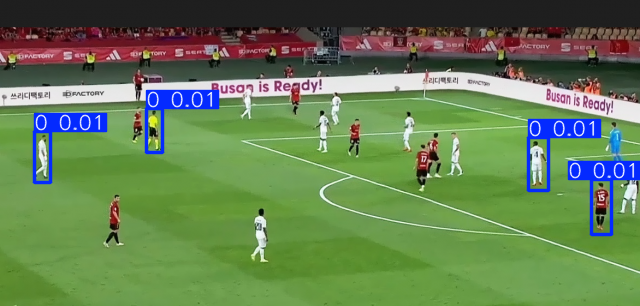

In [28]:
result = model.predict(source=image_path, save=True, conf = 0.01)
result[0].show()  # 탐지된 객체 출력

* 모델의 성능이 낮은 이유는?
    * 데이터 부족 → 훈련 데이터의 양/질 문제
    * 에포크 → 학습 반복 횟수 부족 문제

## (4) 파인튜닝2
* freeze를 조정해서 학습할 모델의 범위를 잡아 본다.

### 1) 학습

* freeze 조정 : model.train( ... , freeze = 10)
    * COCO와 유사·소량 데이터: freeze=10 권장
    * 도메인이 제법 다르다면 : freeze=0 ~ 5
    * 더 보수적으로 접근 : freeze=16 정도

In [31]:
model = YOLO(model='yolo11n.pt', task='detect')

In [32]:
results_train = model.train(model='/content/yolov11n.pt',
                            data='/content/futbol-players-9/data.yaml',
                            epochs=3,
                            seed=20,
                            optimizer = 'Adam',
                            pretrained=True,
                            lr0 = 0.0001,
                            freeze = 10
                            )

Ultralytics 8.3.217 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/futbol-players-9/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/yolov11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train7, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overlap_mask=True, patience=100, perspective=0.0, p

In [33]:
valid_folder = "/content/futbol-players-9/valid/images"  # valid 폴더 경로 지정
image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]  # YOLO에서 지원하는 이미지 확장자

# valid 폴더에서 이미지 파일 개수 확인
image_count = len([f for f in os.listdir(valid_folder) if f.lower().endswith(tuple(image_extensions))])

print(f"Valid 폴더의 이미지 개수: {image_count}")

Valid 폴더의 이미지 개수: 33


### 2) 평가

In [34]:
# 테스트 이미지로 모델 평가하기
results = model.val(data='/content/futbol-players-9/data.yaml', split="test")

Ultralytics 8.3.217 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 789.7±284.5 MB/s, size: 20.4 KB)
val: Scanning /content/futbol-players-9/test/labels.cache... 16 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 16/16 19.7Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.5it/s 0.7s
                   all         16        194     0.0113      0.314      0.279      0.129
                     0         16        173      0.034      0.942      0.837      0.387
                     1          8          8          0          0          0          0
                     2         13         13          0          0          0          0
Speed: 1.4ms preprocess, 5.3ms inference, 0.0ms loss, 11.6ms postprocess per image
Results saved to /content/runs/detect/val6


### 3) 예측해보기

In [35]:
image_path = 'https://m.pressian.com/_resources/10/2023/05/10/2023051008394784314_l.png'


Found https://m.pressian.com/_resources/10/2023/05/10/2023051008394784314_l.png locally at 2023051008394784314_l.png
image 1/1 /content/2023051008394784314_l.png: 320x640 7 0s, 8.6ms
Speed: 1.5ms preprocess, 8.6ms inference, 1.3ms postprocess per image at shape (1, 3, 320, 640)
Results saved to /content/runs/detect/predict7


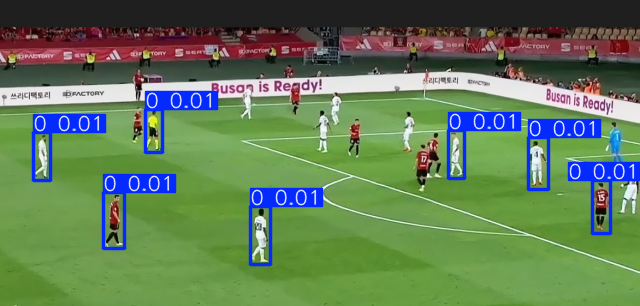

In [36]:
result = model.predict(source=image_path, save=True, conf = 0.01)
result[0].show()  # 탐지된 객체 출력